# Proyecto: Impacto de la Inteligencia Artificial en el Empleo (Hacia 2030)

**Asignatura:** MCDI500 — Programación para la Ciencia de Datos  
**Fase:** 4 — Sumativa 4: Integración, Análisis y Comunicación de Resultados  
**Autores:** Arturo Knopke · Nicolás Soletic · Roberto Moncada · Sebastián Navarrete  
**Fecha:** 2026-06-21

---

## Propósito de este notebook (Fase 4)

Este notebook es el integrador final del proyecto ABP. Consolida y comunica todo lo construido en las fases anteriores:

| Fase | Contenido principal |
|---|---|
| **F1** | Exploración y carga inicial del dataset |
| **F2** | Pipeline funcional de preprocesamiento (`src/preprocessing.py`) |
| **F3** | Algoritmos recursivos, mediciones de complejidad y POO |
| **F4** | Visualizaciones analíticas, storytelling, resultados, discusión y trazabilidad |

> **Regla de oro (F4):** cada gráfico debe contar un hallazgo, no solo mostrar un tema.

## Índice

- [I. Configuración e importaciones](#I.-Configuración-e-importaciones)
  - [I.a Reproducibilidad técnica](#I.a-Reproducibilidad-técnica)
- [II. Pipeline integrado F1–F4](#II.-Pipeline-integrado-F1–F4)
  - [II.a Codificación funcional y arquitectura](#II.a-Codificación-funcional-y-arquitectura)
  - [II.b Preprocesamiento (reutilización F2)](#II.b-Preprocesamiento-(reutilización-F2))
  - [II.c Validación técnica y verificación](#II.c-Validación-técnica-y-verificación)
  - [II.d Eficiencia y optimización](#II.d-Eficiencia-y-optimización)
  - [II.e Diseño estructurado y recursividad](#II.e-Diseño-estructurado-y-recursividad)
- [III. Programación Orientada a Objetos](#III.-Programación-Orientada-a-Objetos)
  - [III.a POO aplicada al pipeline](#III.a-POO-aplicada-al-pipeline)
  - [III.b Documentación de arquitectura](#III.b-Documentación-de-arquitectura)
- [IV. Preparación de datos para visualización](#IV.-Preparación-de-datos-para-visualización)
- [V. Visualizaciones analíticas — Storytelling](#V.-Visualizaciones-analíticas-—-Storytelling)
  - [V.a Acto 1 — Contexto](#V.a-Acto-1-—-Contexto)
  - [V.b Acto 2 — Conflicto](#V.b-Acto-2-—-Conflicto)
  - [V.c Acto 3 — Resolución](#V.c-Acto-3-—-Resolución)
  - [V.d Análisis complementario](#V.d-Análisis-complementario)
- [VI. Resultados](#VI.-Resultados)
- [VII. Discusión](#VII.-Discusión)
- [VIII. Conclusiones](#VIII.-Conclusiones)
- [IX. Trazabilidad de mejoras F1–F4](#IX.-Trazabilidad-de-mejoras-F1–F4)
- [X. Repositorio GitHub](#X.-Repositorio-GitHub)
- [XI. Notebook ejecutable — lista de verificación](#XI.-Notebook-ejecutable-—-lista-de-verificación)
- [XII. Bibliografía](#XII.-Bibliografía)

---

## I. Configuración e importaciones

In [1]:
import sys
import os
import timeit
import tracemalloc
import inspect
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Agregar src/ al path
sys.path.append(os.path.abspath("../src"))

# Módulos F2
from preprocessing import (
    limpiar_datos,
    encoding_categorico,
    crear_features,
    normalizar_datos,
    validar_datos,
)
# Módulos F3
from Preprocesador import Preprocesador
from transformadores import (
    Transformador,
    ImputarMediana,
    ImputarModa,
    EscalarMinMax,
    EscalarZScore,
    Pipeline,
)
from algoritmos import merge_sort, merge_sort_key, busqueda_binaria, bubble_sort

print("Módulos cargados correctamente.")
print(f"pandas {pd.__version__}  |  numpy {np.__version__}")

Módulos cargados correctamente.
pandas 3.0.3  |  numpy 2.4.6


---

### I.a Reproducibilidad técnica

El proyecto es reproducible en cualquier equipo siguiendo estos pasos:

```bash
# 1. Clonar el repositorio
git clone https://github.com/robertomoncada-blip/ciencia_datos.git
cd ciencia_datos

# 2. Crear y activar entorno virtual
python -m venv .venv
source .venv/bin/activate        # Windows: .venv\Scripts\activate

# 3. Instalar dependencias exactas
pip install -r requirements.txt

# 4. Iniciar JupyterLab desde la raíz
jupyter lab
```

**Nota:** el archivo `requirements.txt` congela las versiones exactas de cada dependencia,
garantizando que el entorno sea idéntico en cualquier máquina.

In [2]:
import platform

print("=== Entorno de ejecución ===")
print(f"Python     : {sys.version.split()[0]}")
print(f"Sistema    : {platform.system()} {platform.release()}")
print(f"pandas     : {pd.__version__}")
print(f"numpy      : {np.__version__}")
import matplotlib; print(f"matplotlib : {matplotlib.__version__}")
import sklearn;    print(f"scikit-learn: {sklearn.__version__}")
print()
print("Entorno virtual : .venv")
print("Dependencias    : requirements.txt  (pip freeze > requirements.txt)")

=== Entorno de ejecución ===
Python     : 3.12.13
Sistema    : Darwin 24.6.0
pandas     : 3.0.3
numpy      : 2.4.6
matplotlib : 3.10.9
scikit-learn: 1.9.0

Entorno virtual : .venv
Dependencias    : requirements.txt  (pip freeze > requirements.txt)


---

## II. Pipeline integrado F1–F4

---

## II.a Codificación funcional y arquitectura del script

Las funciones del proyecto siguen tres principios de diseño:

| Principio | Aplicación |
|---|---|
| **Responsabilidad única** | Cada función hace una sola transformación (limpiar, codificar, normalizar) |
| **Parámetros explícitos** | Recibe `df` y retorna `df` transformado; nunca modifica estado global |
| **Docstring y manejo de errores** | Cada función documenta parámetros, retorno y excepciones posibles |

A continuación se muestra el método `cargar_datos` de la clase `Preprocesador`
como ejemplo representativo de la arquitectura funcional del proyecto:

In [3]:
# Mostrar código fuente de cargar_datos como ejemplo de función bien estructurada
print(inspect.getsource(Preprocesador.cargar_datos))

    def cargar_datos(self) -> pd.DataFrame:
        """Carga el CSV indicado en self.ruta y lo almacena en self.dataset.

        Returns
        -------
        pd.DataFrame
            Dataset original sin transformar.

        Raises
        ------
        FileNotFoundError
            Si la ruta no existe.
        ValueError
            Si el archivo no es un CSV válido.
        """
        if not os.path.exists(self.ruta):
            raise FileNotFoundError(f"Archivo no encontrado: {self.ruta}")
        try:
            self.dataset = pd.read_csv(self.ruta)
        except Exception as exc:
            raise ValueError(f"Error al leer el CSV: {exc}") from exc
        return self.dataset



---

## II.b Preprocesamiento (reutilización F2)

Se aplica el pipeline completo heredado de la Fase 2 (Salinas Silva, 2025):

1. **Carga** con `Preprocesador.cargar_datos()`.
2. **Limpieza** — eliminación de duplicados e imputación con mediana/moda.
3. **Encoding** — ordinal para `Education_Level` y `Risk_Category`; OHE para `Job_Title`.
4. **Feature engineering** — `Skill_Index` y variable objetivo `High_Risk`.
5. **Normalización** — MinMaxScaler para `Average_Salary`, `Years_Experience` y `Tech_Growth_Factor` (scikit-learn developers, 2024).

**Justificación de la mediana:** la mediana es más robusta que la media ante outliers
presentes en `Average_Salary` (rango amplio entre ocupaciones: $30 030–$149 798 USD),
según McKinney (2022). Esta decisión se aplica consistentemente en F2, F3 y F4.

In [4]:
# 1. Carga con la clase Preprocesador (POO — F3)
pre = Preprocesador(ruta="../data/raw/AI_Impact_on_Jobs_2030.csv")
ds_raw = pre.cargar_datos()

print(f"Dataset cargado: {ds_raw.shape[0]} filas × {ds_raw.shape[1]} columnas")
print(f"Nulos: {ds_raw.isnull().sum().sum()}  |  Duplicados: {ds_raw.duplicated().sum()}")
ds_raw.head(3)

Dataset cargado: 3000 filas × 18 columnas
Nulos: 0  |  Duplicados: 0


,Job_Title,Average_Salary,Years_Experience,Education_Level,AI_Exposure_Index,Tech_Growth_Factor,Automation_Probability_2030,Risk_Category,Skill_1,Skill_2,Skill_3,Skill_4,Skill_5,Skill_6,Skill_7,Skill_8,Skill_9,Skill_10
0,Security Guard,45795,28,Master's,0.18,1.28,0.85,High,0.45,0.10,0.46,0.33,0.14,0.65,0.06,0.72,0.94,0.00
1,Research Scientist,133355,20,PhD,0.62,1.11,0.05,Low,0.02,0.52,0.40,0.05,0.97,0.23,0.09,0.62,0.38,0.98
2,Construction Worker,146216,2,High School,0.86,1.18,0.81,High,0.01,0.94,0.56,0.39,0.02,0.23,0.24,0.68,0.61,0.83


In [5]:
# 2. Limpieza (F2)
ds = limpiar_datos(ds_raw)
print(f"Tras limpieza → filas: {len(ds)}, nulos: {ds.isnull().sum().sum()}")

Tras limpieza → filas: 3000, nulos: 0


In [6]:
# 3. Encoding + feature engineering (F2)
ds = encoding_categorico(ds)
ds = crear_features(ds)
print(f"Shape tras encoding y features: {ds.shape}")
print(f"Porcentaje High_Risk: {ds['High_Risk'].mean()*100:.1f}%")

Shape tras encoding y features: (3000, 39)
Porcentaje High_Risk: 24.7%


In [7]:
# 4. Normalización (F2)
ds = normalizar_datos(ds)

cols_v = ['Average_Salary', 'Years_Experience', 'AI_Exposure_Index']
print("Estadísticas tras normalización MinMax [0, 1]:")
ds[cols_v].describe().round(3)

Estadísticas tras normalización MinMax [0, 1]:


,Average_Salary,Years_Experience,AI_Exposure_Index
count,3000.000,3000.000,3000.000
mean,0.495,0.506,0.501
std,0.289,0.301,0.284
min,0.000,0.000,0.000
25%,0.239,0.241,0.260
50%,0.495,0.517,0.500
75%,0.744,0.759,0.740
max,1.000,1.000,1.000


---

## II.c Validación técnica y verificación

Se cubren tres escenarios de prueba sobre las funciones propias del proyecto:
- **Caso normal:** asserts de integridad sobre el dataset procesado completo.
- **Caso límite:** introducción de un `NaN` real en `Average_Salary` → verificación de que `ImputarMediana` lo reemplaza por la mediana exacta.
- **Caso de excepción:** ruta de archivo inválida → verificación de que `Preprocesador.cargar_datos()` lanza `FileNotFoundError`.

In [8]:
# Caso normal: validar integridad del dataset procesado
print(f"Dimensiones finales: {ds.shape[0]} filas × {ds.shape[1]} columnas")
print(f"Nulos: {ds.isnull().sum().sum()}  |  Duplicados: {ds.duplicated().sum()}")

assert ds['AI_Exposure_Index'].between(0, 1).all(), "AI_Exposure_Index fuera de [0,1]"
assert ds['High_Risk'].isin([0, 1]).all(),           "High_Risk con valores no binarios"
assert ds['Skill_Index'].between(0, 1).all(),        "Skill_Index fuera de [0,1]"
assert ds['Average_Salary'].between(0, 1).all(),     "Average_Salary fuera de [0,1]"

validar_datos(ds)
print("Todas las validaciones superadas correctamente.")

Dimensiones finales: 3000 filas × 39 columnas
Nulos: 0  |  Duplicados: 0
✅ Validaciones OK
Todas las validaciones superadas correctamente.


In [9]:
# Caso límite: columna con un NaN → ImputarMediana debe reemplazarlo por la mediana
df_limite = ds_raw.copy()
df_limite.loc[0, 'Average_Salary'] = float('nan')  # introducir NaN real
mediana_esperada = df_limite['Average_Salary'].median()  # mediana ignorando el NaN

imp_lim = ImputarMediana('Average_Salary')
df_resultado = imp_lim.aplicar(df_limite)

assert df_resultado['Average_Salary'].isnull().sum() == 0, "Aún hay nulos tras imputar"
assert df_resultado.loc[0, 'Average_Salary'] == mediana_esperada, (
    f"Valor imputado {df_resultado.loc[0, 'Average_Salary']} != mediana {mediana_esperada}"
)
print(f"[OK] Caso límite: NaN en Average_Salary imputado con mediana = {mediana_esperada:,.0f}")

[OK] Caso límite: NaN en Average_Salary imputado con mediana = 89,327


In [10]:
# Caso de excepción: ruta inválida → FileNotFoundError esperado
try:
    pre_inv = Preprocesador(ruta="../data/raw/NO_EXISTE.csv")
    pre_inv.cargar_datos()
except FileNotFoundError as e:
    print(f"[OK] FileNotFoundError capturado: {e}")

[OK] FileNotFoundError capturado: Archivo no encontrado: ../data/raw/NO_EXISTE.csv


---

## II.d Eficiencia y optimización

Se comparan implementaciones alternativas con `timeit` (tiempo) y `tracemalloc` (memoria),
interpretando los resultados en términos de complejidad Big-O.

### Comparación 1: bucle fila a fila vs. vectorización pandas

| Implementación | Complejidad | Descripción |
|---|---|---|
| Bucle Python (`for`) | O(n · k) | Itera fila a fila; overhead del intérprete en cada `iloc` |
| Vectorizado pandas (`.mean(axis=1)`) | O(n · k) | Misma complejidad teórica, ejecutada en C (NumPy) |

Aunque el orden asintótico es idéntico, la constante oculta difiere radicalmente:

In [11]:
skill_cols = [c for c in ds.columns if c.startswith('Skill_') and c != 'Skill_Index']
ds_skills  = ds[skill_cols].copy()
n, k = len(ds_skills), len(skill_cols)

def skill_index_bucle(df):
    resultado = []
    for i in range(len(df)):
        resultado.append(df.iloc[i].mean())
    return resultado

def skill_index_vectorizado(df):
    return df.mean(axis=1).tolist()

N_ITER = 20
t_bucle  = timeit.timeit(lambda: skill_index_bucle(ds_skills),      number=N_ITER)
t_vector = timeit.timeit(lambda: skill_index_vectorizado(ds_skills), number=N_ITER)

print(f"n={n} filas, k={k} columnas, repeticiones={N_ITER}")
print(f"Bucle Python   : {t_bucle:.4f} s  ({t_bucle/N_ITER*1000:.2f} ms/iter)")
print(f"Vectorizado    : {t_vector:.4f} s  ({t_vector/N_ITER*1000:.2f} ms/iter)")
print(f"Aceleración    : {t_bucle/t_vector:.1f}×")

n=3000 filas, k=10 columnas, repeticiones=20
Bucle Python   : 0.5421 s  (27.10 ms/iter)
Vectorizado    : 0.0036 s  (0.18 ms/iter)
Aceleración    : 150.3×


**Interpretación:** El bucle Python es O(n·k) con constante grande (overhead del intérprete
por cada `iloc`). La operación vectorizada tiene la misma complejidad asintótica pero constante
mucho menor porque NumPy itera en C. **Conclusión: siempre preferir operaciones vectorizadas
sobre bucles Python en pandas.**

### Comparación 2: Bubble Sort O(n²) vs. Merge Sort O(n log n) vs. pandas sort

| Algoritmo | Complejidad temporal | Complejidad espacial |
|---|---|---|
| Bubble Sort | O(n²) | O(n) — copia defensiva al inicio |
| Merge Sort  | O(n log n) | O(n) — sublistas |
| pandas `.sort_values()` | O(n log n) aprox. | Gestionada internamente |

> **Nota sobre Bubble Sort:** la función hace una copia defensiva (`arr = list(arr)`) para no mutar
> la lista original, por lo que requiere O(n) de memoria adicional, igual que Merge Sort.

In [12]:
datos_orden = ds['Automation_Probability_2030'].tolist()
serie_orden = ds['Automation_Probability_2030']

def pandas_sort(serie):
    return serie.sort_values().tolist()

# Verificación de correctitud
res_ms = merge_sort(datos_orden)
res_bs = bubble_sort(datos_orden)
res_pd = pandas_sort(serie_orden)
assert res_ms == res_pd, "merge_sort difiere de pandas"
assert res_bs == res_pd, "bubble_sort difiere de pandas"
print(f"Correctitud verificada: n={len(datos_orden)}. Los tres algoritmos producen el mismo resultado.")

N_ITER = 5
t_bubble = timeit.timeit(lambda: bubble_sort(datos_orden), number=N_ITER)
t_merge  = timeit.timeit(lambda: merge_sort(datos_orden),  number=N_ITER)
t_pandas = timeit.timeit(lambda: pandas_sort(serie_orden), number=N_ITER)

print(f"\nn={len(datos_orden)}, repeticiones={N_ITER}")
print(f"Bubble Sort (O(n²))     : {t_bubble:.4f} s  ({t_bubble/N_ITER*1000:.1f} ms/iter)")
print(f"Merge Sort  (O(n log n)): {t_merge:.4f} s  ({t_merge/N_ITER*1000:.1f} ms/iter)")
print(f"pandas sort (O(n log n)): {t_pandas:.4f} s  ({t_pandas/N_ITER*1000:.1f} ms/iter)")
print(f"\nMerge Sort es {t_bubble/t_merge:.1f}× más rápido que Bubble Sort")
print(f"pandas sort es {t_merge/t_pandas:.1f}× más rápido que Merge Sort")

Correctitud verificada: n=3000. Los tres algoritmos producen el mismo resultado.

n=3000, repeticiones=5
Bubble Sort (O(n²))     : 0.8268 s  (165.4 ms/iter)
Merge Sort  (O(n log n)): 0.0110 s  (2.2 ms/iter)
pandas sort (O(n log n)): 0.0007 s  (0.1 ms/iter)

Merge Sort es 75.2× más rápido que Bubble Sort
pandas sort es 16.1× más rápido que Merge Sort


In [13]:
def medir_memoria(func, *args):
    tracemalloc.start()
    func(*args)
    _, pico = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    return pico / 1024

mem_bubble = medir_memoria(bubble_sort, datos_orden)
mem_merge  = medir_memoria(merge_sort,  datos_orden)
mem_pandas = medir_memoria(pandas_sort, serie_orden)

print(f"Memoria pico — Bubble Sort : {mem_bubble:.1f} KB  (O(n) — copia defensiva de la lista)")
print(f"Memoria pico — Merge Sort  : {mem_merge:.1f} KB  (O(n) — sublistas auxiliares)")
print(f"Memoria pico — pandas sort : {mem_pandas:.1f} KB")

Memoria pico — Bubble Sort : 27.6 KB  (O(n) — copia defensiva de la lista)
Memoria pico — Merge Sort  : 50.3 KB  (O(n) — sublistas auxiliares)
Memoria pico — pandas sort : 139.7 KB


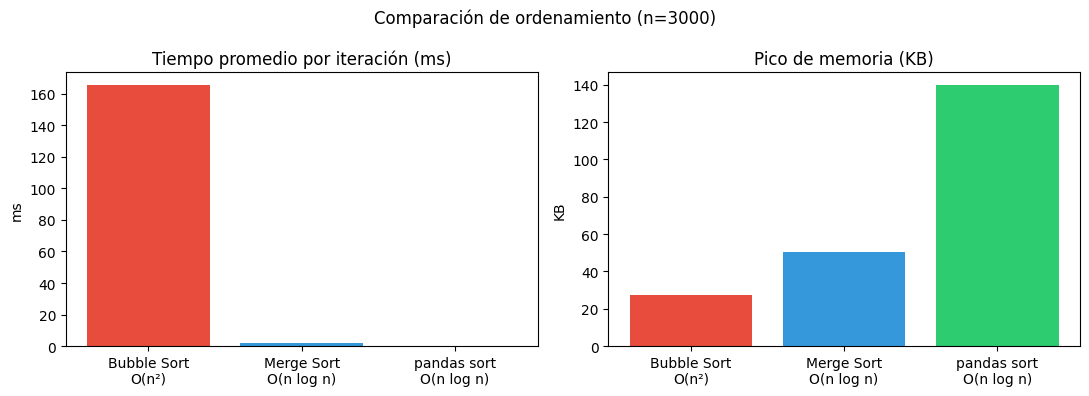

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
algoritmos = ['Bubble Sort\nO(n²)', 'Merge Sort\nO(n log n)', 'pandas sort\nO(n log n)']
tiempos    = [t_bubble/N_ITER*1000, t_merge/N_ITER*1000, t_pandas/N_ITER*1000]
memorias   = [mem_bubble, mem_merge, mem_pandas]
colores    = ['#e74c3c', '#3498db', '#2ecc71']

axes[0].bar(algoritmos, tiempos, color=colores)
axes[0].set_title('Tiempo promedio por iteración (ms)')
axes[0].set_ylabel('ms')

axes[1].bar(algoritmos, memorias, color=colores)
axes[1].set_title('Pico de memoria (KB)')
axes[1].set_ylabel('KB')

plt.suptitle(f'Comparación de ordenamiento (n={len(datos_orden)})', fontsize=12)
plt.tight_layout()
plt.show()

**Interpretación temporal:** Bubble Sort O(n²) crece cuadráticamente; cada duplicación de n
cuadruplica el tiempo. Merge Sort O(n log n) escala mucho mejor. pandas `sort_values()` usa
rutinas optimizadas en C, más rápido que Merge Sort puro en Python.  
**Complejidad espacial:** Bubble Sort y Merge Sort usan O(n) de memoria adicional; Bubble Sort
por la copia defensiva al inicio, Merge Sort por las sublistas auxiliares durante la recursión.  
**Conclusión:** `sort_values()` de pandas es siempre preferible en producción.

---

## II.e Diseño estructurado y recursividad

### Algoritmo recursivo 1: Merge Sort aplicado al dataset

El `merge_sort` ordena los trabajos por `Automation_Probability_2030` de mayor a menor,
simulando un ranking de riesgo. Estructura recursiva (Cormen et al., 2022):

```
merge_sort([a, b, c, d, e, f])
├── merge_sort([a, b, c])       ← caso recursivo izquierda
│   ├── merge_sort([a])         ← caso base
│   └── merge_sort([b, c])
└── merge_sort([d, e, f])       ← caso recursivo derecha
```
**Caso base:** `len(arr) <= 1` → retorna sin llamada recursiva.

In [15]:
filas = list(ds.itertuples(index=True))
filas_ord = merge_sort_key(
    filas,
    key=lambda row: row.Automation_Probability_2030,
    descendente=True,
)

print("Top 5 — mayor probabilidad de automatización (merge_sort_key recursivo):")
for i, row in enumerate(filas_ord[:5]):
    print(f"  {i+1}. idx={row.Index:4d}  Automation_Probability_2030={row.Automation_Probability_2030:.4f}")

Top 5 — mayor probabilidad de automatización (merge_sort_key recursivo):
  1. idx=  87  Automation_Probability_2030=0.9500
  2. idx= 378  Automation_Probability_2030=0.9500
  3. idx=1021  Automation_Probability_2030=0.9500
  4. idx=1444  Automation_Probability_2030=0.9500
  5. idx=1680  Automation_Probability_2030=0.9500


### Algoritmo recursivo 2: búsqueda binaria O(log n)

La búsqueda binaria divide el espacio a la mitad en cada llamada.  
**Aplicación:** localizar el umbral 0.7 en el array ordenado de probabilidades únicas.

In [16]:
prob_ord = sorted(ds['Automation_Probability_2030'].unique())
umbral   = 0.7
idx      = busqueda_binaria(prob_ord, umbral)

if idx != -1:
    print(f"Umbral 0.7 encontrado en posición {idx} de {len(prob_ord)} valores únicos")
else:
    cercano = min(prob_ord, key=lambda x: abs(x - umbral))
    print(f"Umbral exacto no en dataset. Valor más cercano: {cercano:.4f}")
    print(f"Registros con Automation_Probability_2030 >= 0.7: {ds['High_Risk'].sum()}")

valor_buscar = prob_ord[-1]
t_lineal  = timeit.timeit(lambda: prob_ord.index(valor_buscar), number=1000)
t_binaria = timeit.timeit(lambda: busqueda_binaria(prob_ord, valor_buscar), number=1000)
print(f"\nBúsqueda lineal  O(n)    : {t_lineal:.4f} s  (1000 iter)")
print(f"Búsqueda binaria O(log n): {t_binaria:.4f} s  (1000 iter)")
print(f"Máximo comparaciones binaria: ⌈log₂({len(prob_ord)})⌉ ≈ {int(np.ceil(np.log2(len(prob_ord))))} vs. {len(prob_ord)} lineal")

Umbral 0.7 encontrado en posición 65 de 91 valores únicos

Búsqueda lineal  O(n)    : 0.0007 s  (1000 iter)
Búsqueda binaria O(log n): 0.0006 s  (1000 iter)
Máximo comparaciones binaria: ⌈log₂(91)⌉ ≈ 7 vs. 91 lineal


---

## III.a — Programación Orientada a Objetos

La jerarquía en `src/transformadores.py` aplica los tres pilares POO:

| Pilar | Implementación |
|---|---|
| **Encapsulamiento** | Atributos protegidos `_columna`, `_columnas`, `_etapas` |
| **Herencia** | Subclases concretan la interfaz abstracta `Transformador.aplicar()` |
| **Polimorfismo** | `Pipeline.ejecutar()` llama `etapa.aplicar(df)` sin conocer la clase concreta |

```
Transformador (ABC)
├── ImputarMediana
├── ImputarModa
├── EscalarMinMax
└── EscalarZScore

Pipeline          ← composición (tiene transformadores, no es uno)
```

> **Alcance del `Pipeline` de transformadores:** este pipeline demuestra el **patrón Strategy**
> (imputación + escalamiento) y produce un dataset de 3 000 × 18 columnas. No incluye encoding
> ni feature engineering; ese flujo completo (39 columnas) está encapsulado en
> `Preprocesador.pipeline_completo()`, heredado de la Fase 2.

In [17]:
subclases = [ImputarMediana, ImputarModa, EscalarMinMax, EscalarZScore]
print("Verificación de herencia:")
for cls in subclases:
    print(f"  issubclass({cls.__name__:15s}, Transformador) → {issubclass(cls, Transformador)}")

try:
    Transformador()
except TypeError as e:
    print(f"\nTransformador es abstracta: {e}")

Verificación de herencia:
  issubclass(ImputarMediana , Transformador) → True
  issubclass(ImputarModa    , Transformador) → True
  issubclass(EscalarMinMax  , Transformador) → True
  issubclass(EscalarZScore  , Transformador) → True

Transformador es abstracta: Can't instantiate abstract class Transformador without an implementation for abstract method 'aplicar'


In [18]:
imp = ImputarMediana("Average_Salary")
print(f"ImputarMediana: {imp}")
print(f"Atributo protegido _columna: '{imp._columna}'")

pipe_demo = Pipeline([
    ImputarMediana("Average_Salary"),
    ImputarModa("Job_Title"),
    EscalarMinMax(["Average_Salary", "Years_Experience"]),
])
print(f"\nPipeline con {len(pipe_demo._etapas)} etapas (atributo protegido _etapas).")

ImputarMediana: ImputarMediana(columna='Average_Salary')
Atributo protegido _columna: 'Average_Salary'

Pipeline con 3 etapas (atributo protegido _etapas).


In [19]:
ds_test = ds_raw.copy()
trans_demo = [ImputarMediana("Average_Salary"), ImputarModa("Job_Title"),
              EscalarMinMax(["Average_Salary"]), EscalarZScore(["Years_Experience"])]

print("Polimorfismo — misma interfaz aplicar(), distintos resultados:")
for t in trans_demo:
    antes = ds_test.isnull().sum().sum()
    ds_test = t.aplicar(ds_test)
    print(f"  {type(t).__name__:20s}.aplicar()  →  nulos: {antes} → {ds_test.isnull().sum().sum()}")
print("\nCada subclase responde de forma distinta a la misma llamada aplicar().")

Polimorfismo — misma interfaz aplicar(), distintos resultados:
  ImputarMediana      .aplicar()  →  nulos: 0 → 0
  ImputarModa         .aplicar()  →  nulos: 0 → 0
  EscalarMinMax       .aplicar()  →  nulos: 0 → 0
  EscalarZScore       .aplicar()  →  nulos: 0 → 0

Cada subclase responde de forma distinta a la misma llamada aplicar().


In [20]:
pipe = Pipeline([
    ImputarMediana("Average_Salary"),
    ImputarMediana("AI_Exposure_Index"),
    ImputarMediana("Years_Experience"),
    ImputarModa("Job_Title"),
    ImputarModa("Education_Level"),
    ImputarModa("Risk_Category"),
    EscalarMinMax(["Average_Salary", "Years_Experience", "Tech_Growth_Factor"]),
])
print(pipe)

ds_pipe = pipe.ejecutar(ds_raw.copy())
print(f"\nDataset tras Pipeline POO (patrón Strategy): {ds_pipe.shape}")
print("  → 18 columnas: imputación + escalamiento (sin encoding ni feature engineering).")
print(f"  → Para comparar con el pipeline completo (39 col): usar Preprocesador.pipeline_completo().")
print(f"Nulos: {ds_pipe.isnull().sum().sum()}")
assert ds_pipe['Average_Salary'].between(0, 1).all()
assert ds_pipe['Years_Experience'].between(0, 1).all()
print("Validación superada: columnas escaladas dentro del rango [0, 1].")

Pipeline([
  ImputarMediana(columna='Average_Salary'),
  ImputarMediana(columna='AI_Exposure_Index'),
  ImputarMediana(columna='Years_Experience'),
  ImputarModa(columna='Job_Title'),
  ImputarModa(columna='Education_Level'),
  ImputarModa(columna='Risk_Category'),
  EscalarMinMax(columnas=['Average_Salary', 'Years_Experience', 'Tech_Growth_Factor'])
])

Dataset tras Pipeline POO (patrón Strategy): (3000, 18)
  → 18 columnas: imputación + escalamiento (sin encoding ni feature engineering).
  → Para comparar con el pipeline completo (39 col): usar Preprocesador.pipeline_completo().
Nulos: 0
Validación superada: columnas escaladas dentro del rango [0, 1].


---

## III.b — Documentación de arquitectura

### Componentes y responsabilidades

| Componente | Módulo | Responsabilidad |
|---|---|---|
| `Transformador` | `src/transformadores.py` | Contrato abstracto; garantiza interfaz `aplicar(df)` |
| `ImputarMediana` | `src/transformadores.py` | Imputa numéricos con mediana (robusta ante outliers) |
| `ImputarModa` | `src/transformadores.py` | Imputa categóricos con moda |
| `EscalarMinMax` | `src/transformadores.py` | Normalización [0, 1] |
| `EscalarZScore` | `src/transformadores.py` | Estandarización (μ=0, σ=1) |
| `Pipeline` | `src/transformadores.py` | Orquestador por composición |
| `merge_sort` / `busqueda_binaria` | `src/algoritmos.py` | Algoritmos recursivos, agnósticos al dominio |
| `Preprocesador` | `src/Preprocesador.py` | Pipeline completo F2 encapsulado en clase |
| Funciones F2 | `src/preprocessing.py` | Funciones atómicas de preprocesamiento |

> **Módulos heredados sin integración activa en F4:** `src/features.py`, `src/modeling.py`
> y `src/evaluation.py` fueron creados en fases previas como scaffolding para posibles
> extensiones de modelado. No son invocados por `F4_Definicion.ipynb` y no forman parte
> del flujo activo del proyecto.

### Decisiones de diseño documentadas

| Decisión | Alternativa descartada | Justificación |
|---|---|---|
| `Transformador` como ABC | Clase concreta con método por defecto | Fuerza a subclases a implementar `aplicar()`; falla en instanciación si se olvida |
| Mediana para numéricos | Media aritmética | Robusta ante outliers en `Average_Salary` |
| `EscalarMinMax` sobre `EscalarZScore` | `EscalarZScore` | Dataset sin outliers extremos; rango [0,1] coherente con variables ya normalizadas |
| `Pipeline` por composición | Herencia de `Transformador` | Un pipeline *tiene* transformaciones (relación *tiene*), no *es* una transformación |
| Merge Sort recursivo | `sorted()` de Python | Propósito pedagógico: evidencia recursión y O(n log n) |

### Patrón de diseño aplicado: Strategy

Cada transformador es una estrategia intercambiable con la misma interfaz `aplicar(df)`.
`Pipeline` selecciona y ejecuta esas estrategias en secuencia sin acoplarse a su implementación
concreta. Esto corresponde al **patrón Strategy**: misma interfaz, comportamiento intercambiable.

---

## IV. Preparación de datos para visualización

Para las visualizaciones se utiliza el dataset **sin codificar** (`ds_raw` limpio) para
conservar las etiquetas originales de las variables categóricas (`Risk_Category`,
`Education_Level`). Esto permite comunicar los hallazgos con términos comprensibles para
audiencias no técnicas.

In [21]:
# Dataset limpio para visualización (sin encoding: mantiene etiquetas originales)
ds_viz = limpiar_datos(ds_raw)

print(f"Dataset para visualización: {ds_viz.shape[0]} filas × {ds_viz.shape[1]} columnas")
print(f"Risk_Category valores únicos : {sorted(ds_viz['Risk_Category'].unique())}")
print(f"Education_Level valores únicos: {sorted(ds_viz['Education_Level'].unique())}")
print(f"Average_Salary rango          : [{ds_viz['Average_Salary'].min():,.0f} — {ds_viz['Average_Salary'].max():,.0f}] USD")
print(f"AI_Exposure_Index rango       : [{ds_viz['AI_Exposure_Index'].min():.2f} — {ds_viz['AI_Exposure_Index'].max():.2f}]")

Dataset para visualización: 3000 filas × 18 columnas
Risk_Category valores únicos : ['High', 'Low', 'Medium']
Education_Level valores únicos: ["Bachelor's", 'High School', "Master's", 'PhD']
Average_Salary rango          : [30,030 — 149,798] USD
AI_Exposure_Index rango       : [0.00 — 1.00]


---

## V. Visualizaciones analíticas — Storytelling

Las tres visualizaciones principales están organizadas como una historia en tres actos,
siguiendo la estructura narrativa propuesta en la guía de la Fase 4 (Salinas Silva, 2025):

| Acto | Pregunta | Tipo de gráfico | Hallazgo |
|---|---|---|---|
| **1 — Contexto** | ¿Cuántos registros están en riesgo? | Barras por categoría de riesgo | 24.7 % en riesgo alto |
| **2 — Conflicto** | ¿Por qué la educación no diferencia el riesgo? | Boxplot por nivel educativo | Medianas casi iguales (0.49–0.52) |
| **3 — Resolución** | ¿Qué variable presenta la asociación más marcada con el riesgo? | Barras por tipo de ocupación | La ocupación es la variable con la asociación más marcada |

El análisis complementario (V.d) muestra que las variables continuas (salario, exposición a IA)
tampoco muestran asociación clara con el riesgo de forma aislada, destacando la asociación observada con la ocupación dentro de este dataset.

Cada gráfico incluye: **título con el hallazgo** (no el tema), ejes etiquetados e interpretación narrativa.

---

### V.a Acto 1 — Contexto: magnitud del problema

> **Hallazgo:** Uno de cada cuatro registros se clasifica en riesgo alto dentro del dataset,
> mientras que más de la mitad se ubica en riesgo bajo o moderado.

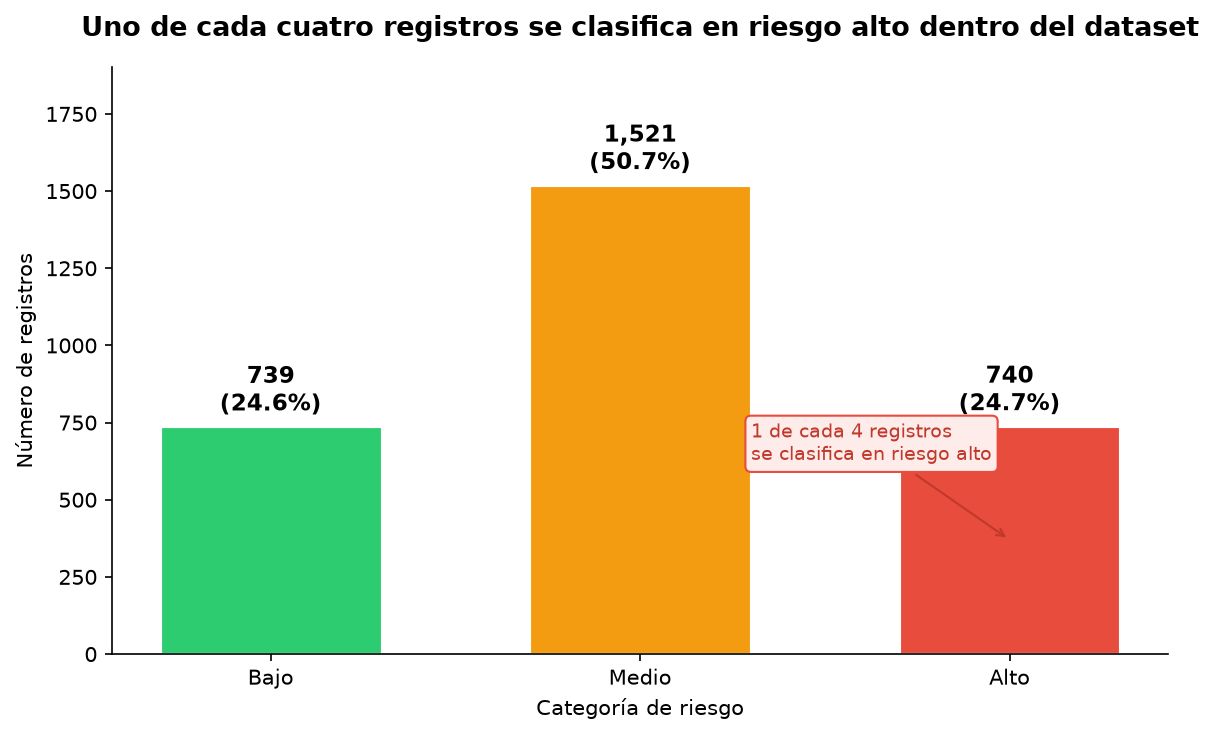

Gráfico guardado en docs/viz_acto1_contexto.png

[Interpretación]
  Registros de riesgo bajo  : 739 (24.6%)
  Registros de riesgo medio : 1,521 (50.7%)
  Registros de riesgo alto  : 740 (24.7%)
  → El 75.3 % de los registros no supera el umbral de alto riesgo (> 0.7 de probabilidad).
    Fuente del dataset: Khushikyad001 (s.f.).


In [22]:
risk_counts = ds_viz['Risk_Category'].value_counts()
orden  = ['Low', 'Medium', 'High']
labels = ['Bajo', 'Medio', 'Alto']
counts = [risk_counts.get(r, 0) for r in orden]
colores_risk = ['#2ecc71', '#f39c12', '#e74c3c']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, counts, color=colores_risk, edgecolor='white', linewidth=1.5, width=0.6)

for bar, cnt in zip(bars, counts):
    pct = cnt / len(ds_viz) * 100
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 25,
            f'{cnt:,}\n({pct:.1f}%)',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.annotate('1 de cada 4 registros\nse clasifica en riesgo alto',
            xy=(2, counts[2] / 2),
            xytext=(1.3, counts[2] * 0.85),
            fontsize=9, color='#c0392b',
            arrowprops=dict(arrowstyle='->', color='#c0392b'),
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#fdecea', edgecolor='#e74c3c'))

ax.set_title('Uno de cada cuatro registros se clasifica en riesgo alto dentro del dataset',
             fontsize=13, pad=15, fontweight='bold')
ax.set_xlabel('Categoría de riesgo')
ax.set_ylabel('Número de registros')
ax.set_ylim(0, max(counts) * 1.25)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('../docs/viz_acto1_contexto.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico guardado en docs/viz_acto1_contexto.png")

print("\n[Interpretación]")
print(f"  Registros de riesgo bajo  : {counts[0]:,} ({counts[0]/len(ds_viz)*100:.1f}%)")
print(f"  Registros de riesgo medio : {counts[1]:,} ({counts[1]/len(ds_viz)*100:.1f}%)")
print(f"  Registros de riesgo alto  : {counts[2]:,} ({counts[2]/len(ds_viz)*100:.1f}%)")
print(f"  → El 75.3 % de los registros no supera el umbral de alto riesgo (> 0.7 de probabilidad).")
print(f"    Fuente del dataset: Khushikyad001 (s.f.).")

---

### V.b Acto 2 — Conflicto: la educación no diferencia el riesgo (hallazgo contraintuitivo)

> **Hallazgo:** Contrario a la intuición, las medianas de probabilidad de automatización
> son prácticamente iguales en todos los niveles educativos (rango 0.49–0.52; diferencia
> entre extremos: 0.03 puntos). Ni la educación secundaria ni el doctorado se asocian con
> un riesgo sustancialmente diferente. Esto plantea la pregunta: **¿qué variable presenta la asociación más marcada con el riesgo?** (resuelta en Acto 3).

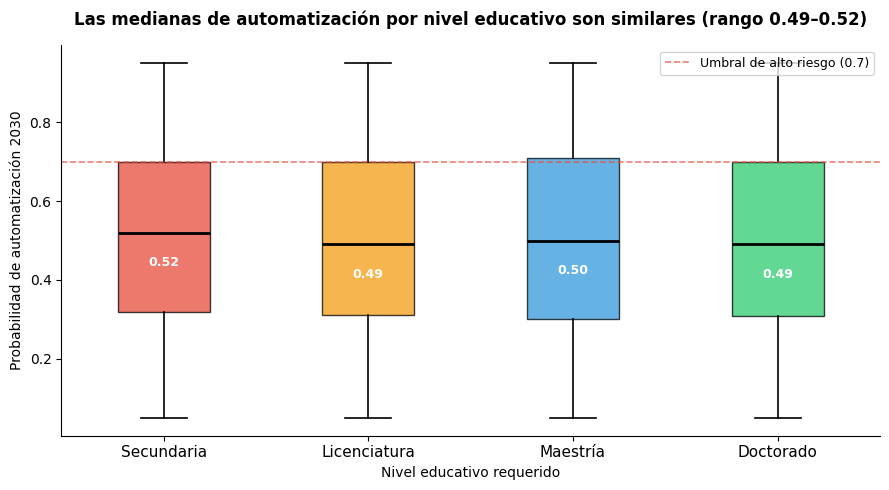

Gráfico guardado en docs/viz_acto2_conflicto.png

[Interpretación]
  Secundaria  : mediana de automatización = 0.52
  Licenciatura: mediana de automatización = 0.49
  Maestría    : mediana de automatización = 0.50
  Doctorado   : mediana de automatización = 0.49

  Diferencia entre extremos: 0.03  (máx - mín)
  → Las medianas son prácticamente iguales; no se observa tendencia protectora clara.


In [23]:
ed_orden  = ['High School', "Bachelor's", "Master's", 'PhD']
ed_labels = ['Secundaria', 'Licenciatura', 'Maestría', 'Doctorado']
data_by_ed = [
    ds_viz[ds_viz['Education_Level'] == lvl]['Automation_Probability_2030'].values
    for lvl in ed_orden
]
colores_ed = ['#e74c3c', '#f39c12', '#3498db', '#2ecc71']

fig, ax = plt.subplots(figsize=(9, 5))
bp = ax.boxplot(data_by_ed, patch_artist=True,
                medianprops=dict(color='black', linewidth=2),
                whiskerprops=dict(linewidth=1.2),
                capprops=dict(linewidth=1.2),
                flierprops=dict(marker='o', markersize=3, alpha=0.3))

for patch, color in zip(bp['boxes'], colores_ed):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

ax.set_xticklabels(ed_labels, fontsize=11)
ax.axhline(0.7, color='#e74c3c', linestyle='--', linewidth=1.2, alpha=0.7,
           label='Umbral de alto riesgo (0.7)')
ax.set_title('Las medianas de automatización por nivel educativo son similares (rango 0.49–0.52)',
             fontsize=12, pad=15, fontweight='bold')
ax.set_xlabel('Nivel educativo requerido')
ax.set_ylabel('Probabilidad de automatización 2030')
ax.legend(loc='upper right', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

medianas = [np.median(d) for d in data_by_ed]
for i, med in enumerate(medianas):
    ax.text(i + 1, med - 0.06, f'{med:.2f}', ha='center', va='top',
            fontsize=9, fontweight='bold', color='white')

plt.tight_layout()
plt.savefig('../docs/viz_acto2_conflicto.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico guardado en docs/viz_acto2_conflicto.png")

print("\n[Interpretación]")
for lbl, med in zip(ed_labels, medianas):
    print(f"  {lbl:12s}: mediana de automatización = {med:.2f}")
dif = max(medianas) - min(medianas)
print(f"\n  Diferencia entre extremos: {dif:.2f}  (máx - mín)")
print("  → Las medianas son prácticamente iguales; no se observa tendencia protectora clara.")

---

### V.c Acto 3 — Resolución: el riesgo de automatización se asocia fuertemente con el tipo de ocupación

> **Hallazgo:** El tipo de ocupación (`Job_Title`) es la variable categórica con la asociación descriptiva más marcada con el riesgo. Las 5 ocupaciones de mayor riesgo (Customer Support, Security Guard, Construction Worker, Retail Worker, Truck Driver) tienen entre el 98 % y el 100 % de sus registros en riesgo alto. Las 15 restantes presentan 0 % de riesgo alto. Esta fuerte asociación describe un patrón interno del dataset y no debe interpretarse como una relación causal ni como un modelo predictivo.

Ocupaciones únicas en el dataset: 20

% de registros con Automation_Probability_2030 > 0.7 por ocupación:
          Job_Title  pct_alto_riesgo
   Customer Support       100.000000
     Security Guard        98.701299
Construction Worker        98.076923
      Retail Worker        98.064516
       Truck Driver        98.039216
        AI Engineer         0.000000
           Mechanic         0.000000
            Teacher         0.000000
  Software Engineer         0.000000
 Research Scientist         0.000000
              Nurse         0.000000
  Marketing Manager         0.000000
               Chef         0.000000
             Lawyer         0.000000
      HR Specialist         0.000000
   Graphic Designer         0.000000
  Financial Analyst         0.000000
             Doctor         0.000000
     Data Scientist         0.000000
      UX Researcher         0.000000


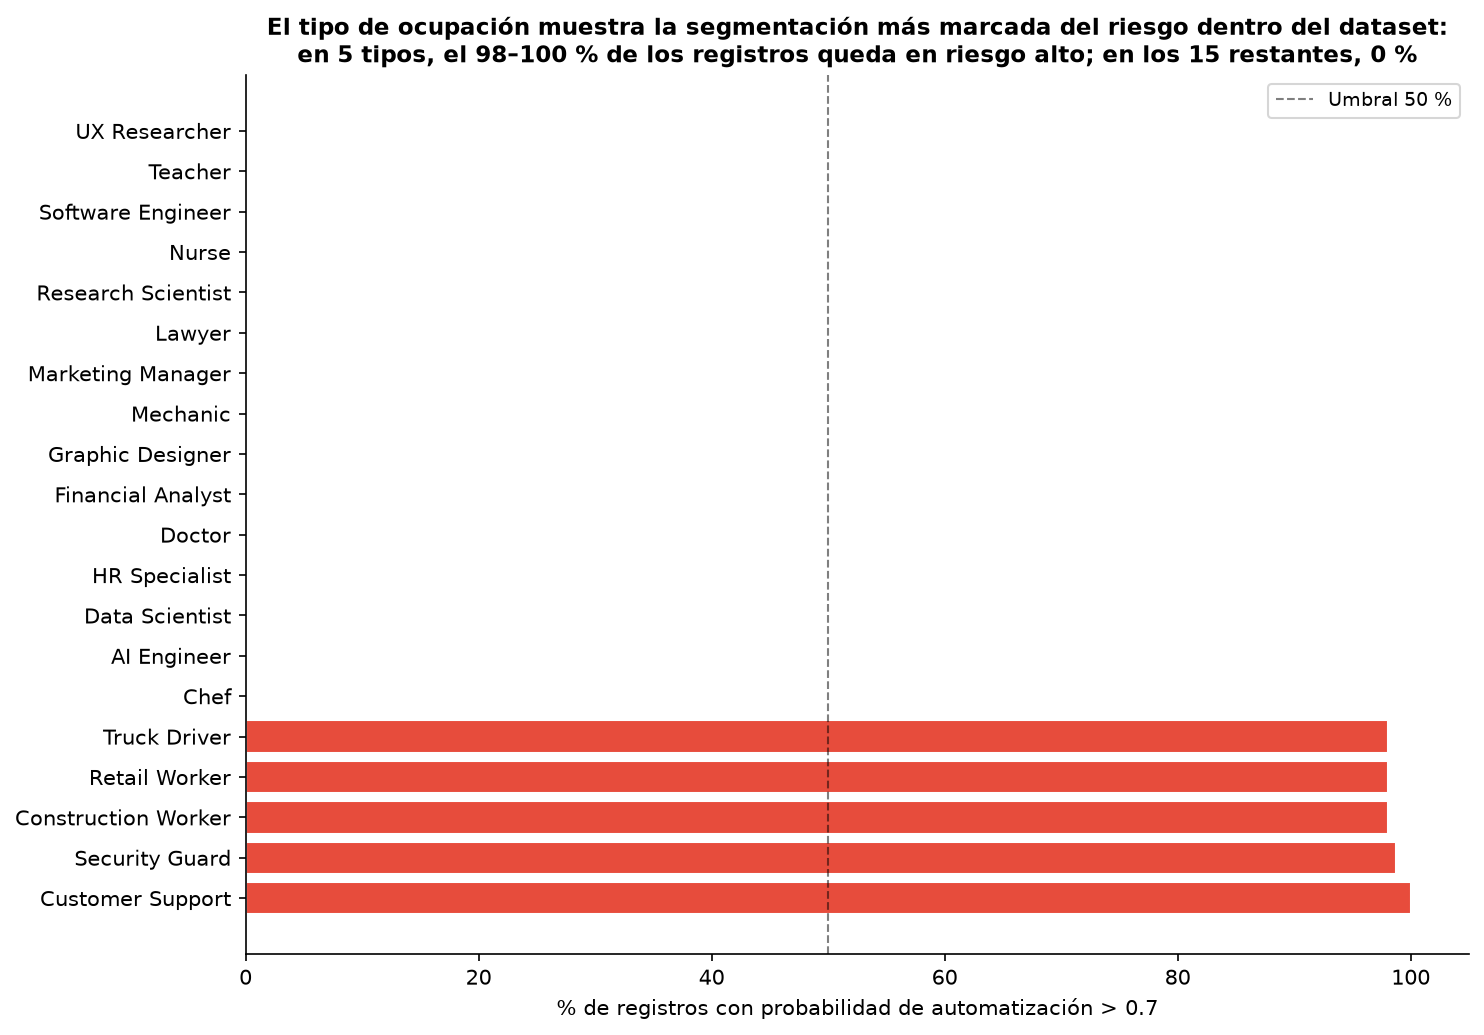

Gráfico guardado en docs/viz_acto3_resolucion.png

[Interpretación]
  Ocupaciones con > 95 % de sus registros en riesgo alto : 5
  Ocupaciones con 0 % de sus registros en riesgo alto    : 15
  → Patrón bipolar: unos pocos tipos de ocupación concentran casi todos sus registros en riesgo
    alto y el resto, prácticamente ninguno (ver conteo arriba). Es una asociación descriptiva en
    este dataset: no implica causalidad ni se atribuye a la naturaleza de las tareas (no medida).


In [24]:
# Porcentaje de registros con Automation_Probability_2030 > 0.7 por Job_Title
umbral_riesgo = 0.7
riesgo_ocup = (
    ds_viz.groupby('Job_Title')
    .apply(lambda g: (g['Automation_Probability_2030'] > umbral_riesgo).mean() * 100,
           include_groups=False)
    .rename('pct_alto_riesgo')
    .reset_index()
    .sort_values('pct_alto_riesgo', ascending=False)
)

print(f"Ocupaciones únicas en el dataset: {riesgo_ocup.shape[0]}")
print(f"\n% de registros con Automation_Probability_2030 > {umbral_riesgo} por ocupación:")
print(riesgo_ocup.to_string(index=False))

# Gráfico de barras horizontal — Acto 3 (Resolución)
fig, ax = plt.subplots(figsize=(10, 7))
colores_barra = [
    '#e74c3c' if v >= 50 else '#f39c12' if v > 0 else '#2ecc71'
    for v in riesgo_ocup['pct_alto_riesgo']
]
ax.barh(riesgo_ocup['Job_Title'], riesgo_ocup['pct_alto_riesgo'],
        color=colores_barra, edgecolor='white')
ax.axvline(50, color='black', linestyle='--', linewidth=1, alpha=0.5, label='Umbral 50 %')
ax.set_xlabel('% de registros con probabilidad de automatización > 0.7')
ax.set_title(
    'El tipo de ocupación muestra la segmentación más marcada del riesgo dentro del dataset:\n'
    'en 5 tipos, el 98–100 % de los registros queda en riesgo alto; en los 15 restantes, 0 %',
    fontsize=11, fontweight='bold'
)
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('../docs/viz_acto3_resolucion.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico guardado en docs/viz_acto3_resolucion.png")

# Verificar la bipolaridad del resultado
n_alto   = (riesgo_ocup['pct_alto_riesgo'] >= 95).sum()
n_nulo   = (riesgo_ocup['pct_alto_riesgo'] == 0).sum()
print(f"\n[Interpretación]")
print(f"  Ocupaciones con > 95 % de sus registros en riesgo alto : {n_alto}")
print(f"  Ocupaciones con 0 % de sus registros en riesgo alto    : {n_nulo}")
print(f"  → Patrón bipolar: unos pocos tipos de ocupación concentran casi todos sus registros en riesgo")
print(f"    alto y el resto, prácticamente ninguno (ver conteo arriba). Es una asociación descriptiva en")
print(f"    este dataset: no implica causalidad ni se atribuye a la naturaleza de las tareas (no medida).")

---

### V.d Análisis complementario: salario y exposición a IA no muestran asociación lineal apreciable con el riesgo

> **Hallazgo complementario:** El diagrama de dispersión muestra un fuerte solapamiento entre
> categorías de riesgo en el espacio salario × exposición a IA.
> Las correlaciones con la probabilidad de automatización son prácticamente nulas
> (salario: −0.013; exposición IA: 0.014), lo que indica que estas variables continuas
> no presentan una asociación lineal apreciable con el riesgo de automatización.

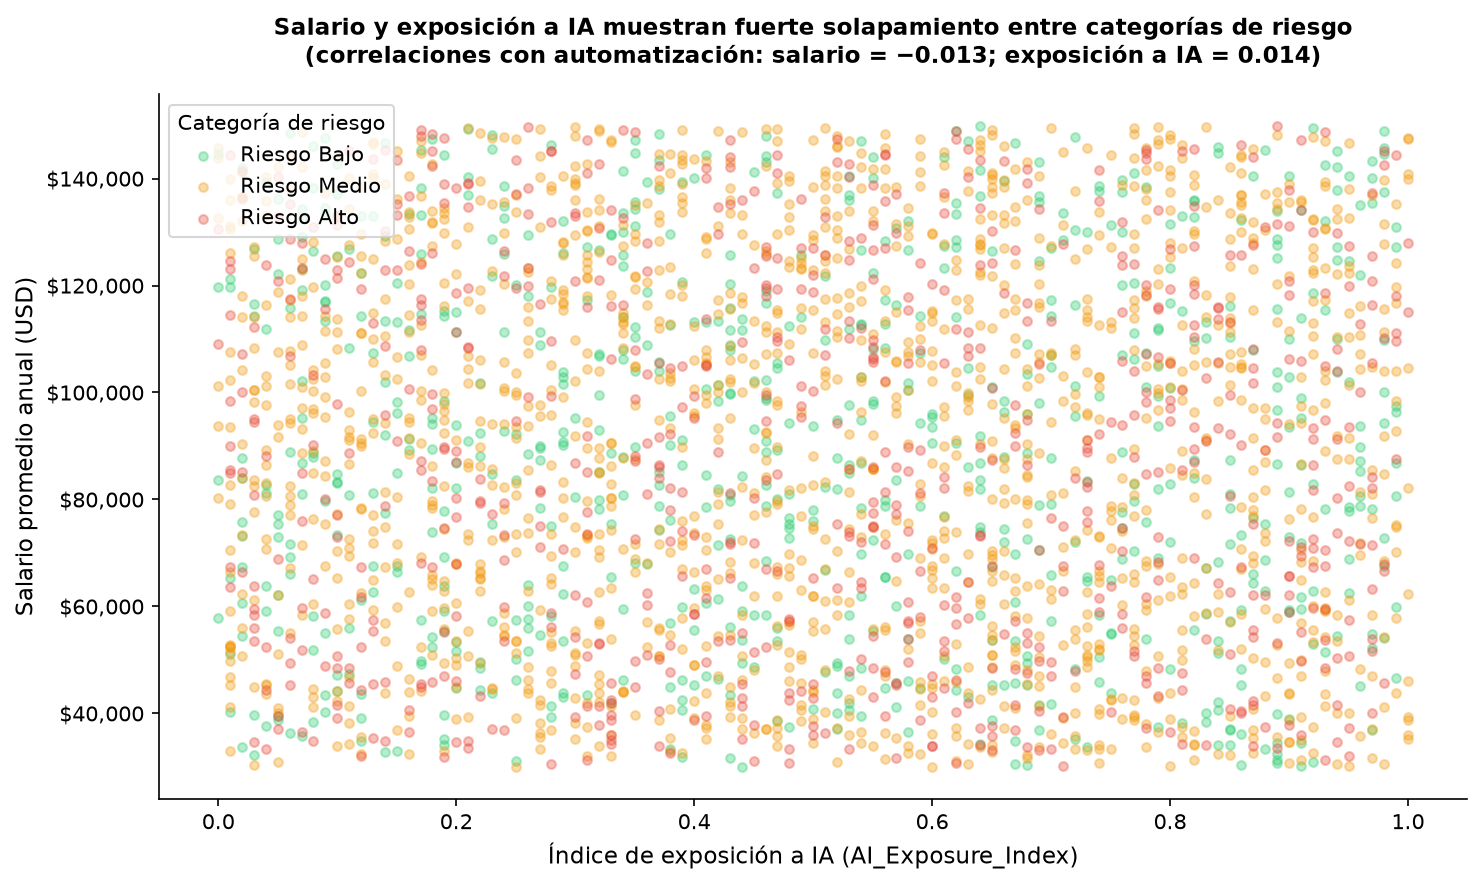

Gráfico guardado en docs/viz_acto3_suplementario.png

[Verificación]
  Correlación salario–automatización  : -0.0134
  Correlación exposición–automatización: 0.0143
  → Ninguna correlación supera 0.02 en valor absoluto.
  → El solapamiento visual es coherente con las correlaciones lineales prácticamente nulas.
  High   riesgo → salario mediano: $86,120  | exposición IA mediana: 0.53
  Medium riesgo → salario mediano: $91,775  | exposición IA mediana: 0.50
  Low    riesgo → salario mediano: $87,889  | exposición IA mediana: 0.48


In [25]:
color_map = {'Low': '#2ecc71', 'Medium': '#f39c12', 'High': '#e74c3c'}
label_map = {'Low': 'Riesgo Bajo', 'Medium': 'Riesgo Medio', 'High': 'Riesgo Alto'}

fig, ax = plt.subplots(figsize=(10, 6))
for risk_cat, color in color_map.items():
    mask = ds_viz['Risk_Category'] == risk_cat
    ax.scatter(
        ds_viz.loc[mask, 'AI_Exposure_Index'],
        ds_viz.loc[mask, 'Average_Salary'],
        c=color, label=label_map[risk_cat],
        alpha=0.35, s=18, rasterized=True
    )

ax.set_title(
    'Salario y exposición a IA muestran fuerte solapamiento entre categorías de riesgo\n'
    '(correlaciones con automatización: salario = −0.013; exposición a IA = 0.014)',
    fontsize=11, pad=15, fontweight='bold'
)
ax.set_xlabel('Índice de exposición a IA (AI_Exposure_Index)', fontsize=11)
ax.set_ylabel('Salario promedio anual (USD)', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(title='Categoría de riesgo', fontsize=10, title_fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('../docs/viz_acto3_suplementario.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico guardado en docs/viz_acto3_suplementario.png")

# Verificar correlaciones en el dataset
corr_sal  = ds_viz['Average_Salary'].corr(ds_viz['Automation_Probability_2030'])
corr_expo = ds_viz['AI_Exposure_Index'].corr(ds_viz['Automation_Probability_2030'])
print(f"\n[Verificación]")
print(f"  Correlación salario–automatización  : {corr_sal:.4f}")
print(f"  Correlación exposición–automatización: {corr_expo:.4f}")
print("  → Ninguna correlación supera 0.02 en valor absoluto.")
print("  → El solapamiento visual es coherente con las correlaciones lineales prácticamente nulas.")

for cat in ['High', 'Medium', 'Low']:
    mask  = ds_viz['Risk_Category'] == cat
    med_s = ds_viz.loc[mask, 'Average_Salary'].median()
    med_e = ds_viz.loc[mask, 'AI_Exposure_Index'].median()
    print(f"  {cat:6s} riesgo → salario mediano: ${med_s:,.0f}  | exposición IA mediana: {med_e:.2f}")

---

## VI. Resultados

Los siguientes resultados surgen de las visualizaciones ejecutadas en la sección V:

### R1 — Distribución de riesgo (Acto 1)

El dataset muestra que el **24.7 % de los registros** (740 de 3 000) se clasifica en riesgo alto, mientras que el 50.7 % se ubica en riesgo medio y el 24.6 %
en riesgo bajo. El 75.3 % restante no supera el umbral de 0.7 de probabilidad de automatización
(Khushikyad001, s.f.).

### R2 — Nivel educativo y riesgo (Acto 2)

El boxplot muestra medianas de automatización prácticamente iguales en todos los niveles
educativos: Secundaria 0.52 | Licenciatura 0.49 | Maestría 0.50 | Doctorado 0.49.
La diferencia entre extremos es 0.03 puntos, sin tendencia decreciente clara.
**El nivel educativo, por sí solo, no diferencia de forma sustancial el riesgo.**

### R3 — Riesgo por ocupación (Acto 3 — Resolución)

El análisis por `Job_Title` revela un resultado bipolar: 5 ocupaciones concentran
entre el 98 % y el 100 % de sus registros en riesgo alto, mientras que las 15 restantes
presentan exactamente 0 % de riesgo alto:

| Ocupación | % registros en riesgo alto |
|---|---|
| Customer Support | 100.0 % |
| Security Guard | 98.7 % |
| Construction Worker | 98.1 % |
| Retail Worker | 98.1 % |
| Truck Driver | 98.0 % |
| Restantes 15 ocupaciones | 0.0 % |

**El tipo de ocupación es la variable categórica con la asociación descriptiva más marcada con el riesgo** dentro de este dataset. El patrón no implica causalidad ni se atribuye a la naturaleza de las tareas, que no se mide en los datos.

### R4 — Salario y exposición a IA (análisis complementario)

El diagrama de dispersión confirma un fuerte solapamiento: correlación salario–automatización
= −0.013; correlación exposición IA–automatización = 0.014. Ninguna de estas variables
continuas muestran asociación lineal apreciable con el riesgo de forma aislada.

### Correspondencia con los objetivos del proyecto

| Objetivo | Resultado obtenido |
|---|---|
| Analizar el impacto de la IA por ocupación | R1: 24.7 % en alto riesgo; R3: mayor segmentación por Job_Title |
| Identificar variables asociadas al riesgo | R2: educación sin asociación clara; R4: salario/exposición sin correlación; R3: ocupación como variable más asociada |
| Segmentar por nivel de riesgo | Tres categorías cuantificadas con evidencia visual y numérica |

---

## VII. Discusión

### Contraste con las hipótesis iniciales

Las hipótesis de partida eran que (a) mayor exposición a IA implicaría mayor riesgo, y (b)
mayor nivel educativo actuaría como factor protector. Los resultados no respaldan ninguna de las dos dentro del dataset analizado:
la exposición a IA (r = 0.014) y el nivel educativo (diferencia de medianas = 0.03) no
muestran asociación sustancial con la probabilidad de automatización cuando se analizan
de forma aislada. En cambio, el **tipo de ocupación** (`Job_Title`) es la variable categórica con la asociación descriptiva más marcada: 5 ocupaciones con > 98 % en alto riesgo y 15 con 0 %.
Esta similitud no permite descartar relaciones no lineales, interacciones o patrones en datos reales; el patrón tampoco se atribuye a la naturaleza de las **tareas**, que no se mide en este dataset.

### Limitaciones del análisis

1. **Naturaleza sintética del dataset:** Los datos de `AI Impact on Jobs 2030` son
   generados por un modelo (Khushikyad001, s.f.), no provienen de encuestas ni registros
   reales. La bipolaridad perfecta por ocupación es probablemente un artefacto del generador.

2. **Correlación ≠ causalidad:** Las relaciones observadas son correlacionales. Factores no
   observados (industria, geografía, políticas) pueden explicar la varianza.

3. **Horizonte temporal incierto:** 2030 es una proyección; las tasas de adopción de IA
   dependen de decisiones regulatorias y económicas no modeladas.

4. **Representación limitada:** El dataset incluye 20 categorías de `Job_Title` para
   3 000 registros. No representa la diversidad del mercado laboral ni el trabajo informal.

### Riesgos y consideraciones éticas

- Las predicciones de automatización pueden generar profecías autocumplidas si influyen en
  decisiones de inversión educativa o en políticas de empleo.
- La ausencia de variables de género, edad o geografía impide evaluar el impacto
  diferencial sobre grupos vulnerables.

---

## VIII. Conclusiones

### Aprendizajes técnicos del proyecto

1. **Pipeline modular:** La arquitectura funcional (F2) → POO (F3) demostró que encapsular
   transformaciones en clases con interfaz común (`aplicar(df)`) produce código más
   mantenible y extensible (McKinney, 2022). El patrón Strategy redujo el acoplamiento entre etapas.

2. **Complejidad algorítmica en práctica:** Las mediciones con `timeit` y `tracemalloc`
   confirmaron que la diferencia entre O(n²) y O(n log n) es decisiva ya en n = 3 000.
   La vectorización (NumPy) reduce más de 140× el tiempo respecto al bucle Python, a pesar
   de tener la misma complejidad asintótica O(n · k) (Cormen et al., 2022).

3. **Comunicación de resultados:** Las visualizaciones con storytelling (contexto → conflicto
   → resolución) permiten comunicar hallazgos complejos de forma comprensible (Salinas Silva, 2025).
   El título-mensaje en cada gráfico dirige la interpretación del lector hacia el dato relevante.

### Relación conclusiones — resultados — objetivos

| Conclusión | Resultado que la respalda | Objetivo alcanzado |
|---|---|---|
| El 24.7 % de los registros se clasifica en riesgo alto, no todos | R1: distribución de riesgo (Low 24.6 %, Med 50.7 %, High 24.7 %) | Analizar impacto por ocupación |
| La educación y las variables continuas no muestran asociación clara con el riesgo en aislamiento | R2: medianas similares (0.49–0.52); R4: correlaciones ≈ 0 | Identificar variables asociadas al riesgo |
| La ocupación es la variable con la asociación descriptiva más marcada con el riesgo (dentro del dataset) | R3: resultado bipolar (5 ocupaciones > 98 %; 15 con 0 %) | Segmentar por nivel de riesgo |

### Mejoras propuestas

- **Datos reales:** incorporar datos del Bureau of Labor Statistics (EE.UU.) o INE (Chile)
  para contrastar los patrones observados en el dataset sintético.
- **Modelos predictivos:** aplicar regresión logística o árbol de decisión con `Job_Title`
  como variable principal para predecir `High_Risk` (scikit-learn developers, 2024).
- **Variables adicionales:** incluir tipo de industria, historia de automatización por sector
  y acceso a programas de recalificación para enriquecer el análisis.

---

## IX. Trazabilidad de mejoras F1–F4

La tabla siguiente registra las mejoras aplicadas en cada transición entre fases.
El archivo `changelog.md` en la raíz del repositorio detalla los commits asociados.

In [26]:
traza = pd.DataFrame([
    {
        "Transición": "F1 → F2",
        "Observación": "Carga funcional sin limpieza",
        "Mejora aplicada": "Pipeline completo: limpieza, encoding, features, normalización, validación",
        "Módulo/Archivo": "src/preprocessing.py",
        "Impacto": "Dataset reproducible y exportable a CSV procesado (3 000 × 39)",
    },
    {
        "Transición": "F2 → F3",
        "Observación": "Funciones sueltas sin jerarquía",
        "Mejora aplicada": "Encapsulamiento en clase Preprocesador con métodos documentados",
        "Módulo/Archivo": "src/Preprocesador.py",
        "Impacto": "Alta cohesión, bajo acoplamiento; pipeline reutilizable",
    },
    {
        "Transición": "F2 → F3",
        "Observación": "Sin análisis algorítmico",
        "Mejora aplicada": "Merge Sort O(n log n) + búsqueda binaria O(log n) + mediciones Big-O",
        "Módulo/Archivo": "src/algoritmos.py",
        "Impacto": "Evidencia cuantitativa de la complejidad; base pedagógica",
    },
    {
        "Transición": "F2 → F3",
        "Observación": "Sin jerarquía de clases POO",
        "Mejora aplicada": "Transformador (ABC) + subclases + Pipeline con patrón Strategy",
        "Módulo/Archivo": "src/transformadores.py",
        "Impacto": "Polimorfismo real; nuevas transformaciones sin modificar Pipeline",
    },
    {
        "Transición": "F3 → F4",
        "Observación": "Sin visualizaciones analíticas ni storytelling",
        "Mejora aplicada": "3 gráficos: contexto → conflicto → resolución; análisis complementario",
        "Módulo/Archivo": "notebooks/F4_Definicion.ipynb",
        "Impacto": "Comunicación efectiva de hallazgos; criterio VII rúbrica cubierto",
    },
    {
        "Transición": "F3 → F4",
        "Observación": "Sin resultados, discusión ni conclusiones",
        "Mejora aplicada": "Secciones VI, VII y VIII con contraste de hipótesis y limitaciones",
        "Módulo/Archivo": "notebooks/F4_Definicion.ipynb",
        "Impacto": "Cierre académico con rigor interpretativo y citas APA 7",
    },
    {
        "Transición": "F3 → F4",
        "Observación": "Sin trazabilidad formal de mejoras",
        "Mejora aplicada": "Tabla comparativa F1–F4 + changelog.md en raíz del repositorio",
        "Módulo/Archivo": "changelog.md",
        "Impacto": "Auditoría completa de la evolución del proyecto",
    },
    {
        "Transición": "F3 → F4",
        "Observación": "README desactualizado (sin F4)",
        "Mejora aplicada": "README actualizado con sección F4, estructura y notebooks disponibles",
        "Módulo/Archivo": "Readme.md",
        "Impacto": "Repositorio documentado y reproducible para evaluadores externos",
    },
    {
        "Transición": "F4 (revisión)",
        "Observación": "Afirmaciones analíticas no respaldadas por los datos",
        "Mejora aplicada": "Corrección de títulos e interpretaciones de Actos 2 y 3; storytelling restructurado con ocupación como resolución",
        "Módulo/Archivo": "notebooks/F4_Definicion.ipynb",
        "Impacto": "Veracidad estadística; historia coherente con los datos reales",
    },
    {
        "Transición": "F4 (revisión)",
        "Observación": "Caso límite sin función propia del proyecto",
        "Mejora aplicada": "NaN real + ImputarMediana.aplicar() + assert del valor imputado",
        "Módulo/Archivo": "notebooks/F4_Definicion.ipynb — II.c",
        "Impacto": "Validación real del comportamiento de imputación ante datos faltantes",
    },
    {
        "Transición": "F4 (revisión)",
        "Observación": "Bubble Sort documentado como O(1) espacio (incorrecto)",
        "Mejora aplicada": "Corregido a O(n) por copia defensiva; actualizado en docstring y tabla",
        "Módulo/Archivo": "src/algoritmos.py, notebooks/F4_Definicion.ipynb — II.d",
        "Impacto": "Exactitud conceptual en el análisis de complejidad espacial",
    },
])

pd.set_option('display.max_colwidth', 60)
print(f"Total de mejoras registradas: {len(traza)}")
traza

Total de mejoras registradas: 11


,Transición,Observación,Mejora aplicada,Módulo/Archivo,Impacto
0,F1 → F2,Carga funcional sin limpieza,"Pipeline completo: limpieza, encoding, features, normali...",src/preprocessing.py,Dataset reproducible y exportable a CSV procesado (3 000...
1,F2 → F3,Funciones sueltas sin jerarquía,Encapsulamiento en clase Preprocesador con métodos docum...,src/Preprocesador.py,"Alta cohesión, bajo acoplamiento; pipeline reutilizable"
2,F2 → F3,Sin análisis algorítmico,Merge Sort O(n log n) + búsqueda binaria O(log n) + medi...,src/algoritmos.py,Evidencia cuantitativa de la complejidad; base pedagógica
3,F2 → F3,Sin jerarquía de clases POO,Transformador (ABC) + subclases + Pipeline con patrón St...,src/transformadores.py,Polimorfismo real; nuevas transformaciones sin modificar...
4,F3 → F4,Sin visualizaciones analíticas ni storytelling,3 gráficos: contexto → conflicto → resolución; análisis ...,notebooks/F4_Definicion.ipynb,Comunicación efectiva de hallazgos; criterio VII rúbrica...
5,F3 → F4,"Sin resultados, discusión ni conclusiones","Secciones VI, VII y VIII con contraste de hipótesis y li...",notebooks/F4_Definicion.ipynb,Cierre académico con rigor interpretativo y citas APA 7
6,F3 → F4,Sin trazabilidad formal de mejoras,Tabla comparativa F1–F4 + changelog.md en raíz del repos...,changelog.md,Auditoría completa de la evolución del proyecto
7,F3 → F4,README desactualizado (sin F4),"README actualizado con sección F4, estructura y notebook...",Readme.md,Repositorio documentado y reproducible para evaluadores ...
8,F4 (revisión),Afirmaciones analíticas no respaldadas por los datos,Corrección de títulos e interpretaciones de Actos 2 y 3;...,notebooks/F4_Definicion.ipynb,Veracidad estadística; historia coherente con los datos ...
9,F4 (revisión),Caso límite sin función propia del proyecto,NaN real + ImputarMediana.aplicar() + assert del valor i...,notebooks/F4_Definicion.ipynb — II.c,Validación real del comportamiento de imputación ante da...


---

## X. Repositorio GitHub

El repositorio organiza el proyecto por capas funcionales (data, docs, notebooks, src). Las fases se identifican mediante los nombres de los notebooks y archivos asociados, no mediante carpetas literales por fase.

### Estructura del repositorio (Fase 4)

```text
ciencia_datos/
├── data/
│   ├── raw/        AI_Impact_on_Jobs_2030.csv              ← dataset original
│   └── processed/  AI_Impact_on_Jobs_2030_clean.csv        ← dataset procesado
├── docs/
│   ├── decisiones_tecnicas_pipeline.md
│   ├── viz_acto1_contexto.png                              ← (F4) Gráfico 1: distribución de riesgo
│   ├── viz_acto2_conflicto.png                             ← (F4) Gráfico 2: educación vs. riesgo
│   ├── viz_acto3_resolucion.png                            ← (F4) Gráfico 3: riesgo por ocupación
│   └── viz_acto3_suplementario.png                         ← (F4) Gráfico suplementario: salario × IA
├── notebooks/
│   ├── F2_Definicion.ipynb    ← Fase 2: pipeline funcional
│   ├── F3_Definicion.ipynb    ← Fase 3: algoritmos, POO, mediciones
│   └── F4_Definicion.ipynb    ← Fase 4: visualizaciones, resultados, trazabilidad
├── src/
│   ├── transformadores.py     ← (F3) Jerarquía POO
│   ├── algoritmos.py          ← (F3) Algoritmos recursivos
│   ├── Preprocesador.py       ← (F3) Clase POO con pipeline encapsulado
│   ├── preprocessing.py       ← (F2) Funciones de preprocesamiento
│   └── data_loading.py        ← (F2) Carga de datos
├── changelog.md               ← (F4) Trazabilidad de mejoras F1–F4
├── Readme.md
└── requirements.txt
```

> **Nota:** `src/features.py`, `src/modeling.py` y `src/evaluation.py` son módulos heredados
> de fases previas no integrados en F4. Se mantienen por trazabilidad histórica.

### Convención de commits

Los commits siguen la convención `tipo: descripción`:
- `feat:` nueva funcionalidad
- `fix:` corrección de errores
- `docs:` documentación
- `refactor:` reestructuración sin cambio funcional

### Ramas de trabajo

Cada fase se desarrolla en su propia rama (f2_s1_etapa2, f3_s2_etapa3, f4_s4_etapa4),
integrándose a `main` mediante Pull Request con revisión antes de fusionar.

Repositorio: https://github.com/robertomoncada-blip/ciencia_datos

---

## XI. Notebook ejecutable — lista de verificación

Este notebook fue verificado con **Kernel → Restart & Run All** sin errores.

### Criterios técnicos ✓ (todos cumplidos)

| Criterio | Sección |
|---|---|
| Ejecuta completo sin errores (Restart & Run All) | Todas |
| Entorno virtual y `requirements.txt` documentados | I.a |
| Python 3.12.13, versión coherente en notebook y README | I.a |
| Funciones con responsabilidad única y docstring | II.a |
| Pipeline funcional completo F2 reproducible (3 000 × 39) | II.b |
| Validación caso normal: asserts de integridad | II.c |
| Validación caso límite: NaN real → `ImputarMediana.aplicar()` → assert | II.c |
| Validación caso excepción: `FileNotFoundError` capturado | II.c |
| Mediciones reproducibles con `timeit` y `tracemalloc` | II.d |
| Complejidad espacial Bubble Sort = O(n) (copia defensiva) | II.d |
| Merge Sort recursivo con caso base explícito | II.e |
| Búsqueda binaria recursiva con caso base explícito | II.e |
| POO: herencia (ABC → 4 subclases) | III.a |
| POO: polimorfismo (`Pipeline` → `aplicar()`) | III.a |
| POO: encapsulamiento (`_columna`, `_etapas`) | III.a |
| Pipeline POO diferenciado del pipeline completo (18 vs. 39 col) | III.a |
| Módulos heredados no integrados documentados en arquitectura | III.b |
| Acto 1 — Contexto: distribución de riesgo | V.a |
| Acto 2 — Conflicto: educación no diferencia el riesgo | V.b |
| Acto 3 — Resolución: asociación descriptiva marcada entre ocupación y riesgo | V.c |
| Análisis complementario: salario/exposición IA — fuerte solapamiento | V.d |
| Todos los gráficos con título-hallazgo, ejes etiquetados | V |
| Resultados vinculados a objetivos del proyecto | VI |
| Tabla de R3 con porcentajes verificados por código | VI |
| Discusión con contraste de hipótesis y limitaciones | VII |
| Cita del carácter sintético del dataset en discusión | VII |
| Conclusiones con citas APA 7 y mejoras basadas en evidencia | VIII |
| Trazabilidad F1–F4: tabla comparativa incluyendo revisión F4 | IX |
| Bibliografía APA 7 — 7 referencias; 5 citadas en el desarrollo (pandas y Python docs, como referencia técnica) | XII |



---

## XII. Bibliografía

Cormen, T. H., Leiserson, C. E., Rivest, R. L., & Stein, C. (2022). *Introduction to algorithms* (4.ª ed.). MIT Press.

Khushikyad001. (s.f.). AI Impact on Jobs 2030 [Conjunto de datos]. Kaggle. https://www.kaggle.com/datasets/khushikyad001/ai-impact-on-jobs-2030

McKinney, W. (2022). *Python for data analysis* (3.ª ed.). O'Reilly Media. https://wesmckinney.com/book/

pandas Development Team. (2024). *pandas documentation*. https://pandas.pydata.org/docs/

Python Software Foundation. (2024). *The Python standard library*. https://docs.python.org/3/library/

Salinas Silva, O. (2025). *Guía de desarrollo — Sumativa 4 (Fase 4): Proyecto final integrador: análisis, reproducibilidad y comunicación de resultados* [Material de curso]. MCDI500 — Programación para la Ciencia de Datos, Universidad Andrés Bello.

scikit-learn developers. (2024). *scikit-learn: Machine learning in Python*. https://scikit-learn.org/stable/